In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors as colors

from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [7]:
df = pd.read_csv('data/churn_preprocessed.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,True,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,True,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,True,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,True,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,True,0.0,Mobile,1,12.0,Credit Card,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [8]:
# eda 용 복사본
df_eda = df.copy()

In [9]:
float_columns = df_eda.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns:")
print(list(float_columns))
print()

object_columns = df_eda.select_dtypes(include=['object']).columns
print("Object columns:")
print(list(object_columns))
print()

ordinal_columns = ['CityTier', 'SatisfactionScore', 'Complain']
print("Ordinal columns:")
print(ordinal_columns)

Numeric columns:
['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Object columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Ordinal columns:
['CityTier', 'SatisfactionScore', 'Complain']


In [10]:
# 수치형 컬럼 결측치 중앙값으로 채우기  
float_medians = df_eda[float_columns].median()
df_eda[float_columns] = df_eda[float_columns].fillna(float_medians)
print(df_eda[float_columns].isnull().sum())

CustomerID                     0
Tenure                         0
CityTier                       0
WarehouseToHome                0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
SatisfactionScore              0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


In [11]:
# 수치형 컬럼 통계 요약
df_eda[float_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Tenure,5630.0,10.134103,8.357951,0.0,3.00,9.00,15.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5630.0,15.566785,8.345961,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5630.0,2.934636,0.705528,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00
OrderAmountHikeFromlastYear,5630.0,15.674600,3.591058,11.0,13.00,15.00,18.0000,26.00


In [12]:
# 범주형 컬럼 분포 확인
for col in object_columns:
    print(f"[{col}]")
    print(df_eda[col].value_counts().sort_values(ascending=False))
    print()

[PreferredLoginDevice]
PreferredLoginDevice
Mobile      3996
Computer    1634
Name: count, dtype: int64

[PreferredPaymentMode]
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

[Gender]
Gender
Male      3384
Female    2246
Name: count, dtype: int64

[PreferedOrderCat]
PreferedOrderCat
Mobile                2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

[MaritalStatus]
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64



In [13]:
# EDA 용 함수
def split_on_capitals(text):
    new_text = [text[0]]
    for char in text[1:]:
        if char.isupper():
            new_text.append(' ')
        new_text.append(char)
    return ''.join(new_text).title()

### churn

In [14]:
# churn 분포 시각화
churn_counts = df_eda['Churn'].value_counts()

labels = ['No', 'Yes']
pie_colors = [px.colors.qualitative.Pastel1[2], px.colors.qualitative.Pastel1[0]]

fig = px.pie(
    names=labels,
    values=churn_counts,
    title='Churn Distribution',
    labels={'names': 'Churn', 'values': 'Count'},
    color_discrete_sequence=pie_colors,
    hover_name=labels,
    hole=0.4
)

fig.update_traces(textinfo='percent+label')

fig.update_layout(
    title_text='Churn Distribution',
    title_x=0.5,
    title_y=0.9,
    title_font_size=20
)

fig.show()

In [15]:
churn_ratio = df_eda['Churn'].value_counts(normalize=True) * 100
print(churn_ratio)

Churn
False    83.161634
True     16.838366
Name: proportion, dtype: float64


- 이탈률이 16.8% 낮음

In [16]:
# 범주형 변수별 churn 분포
fig = go.Figure()

for column in object_columns:
    counts = df_eda.groupby([column, 'Churn']).size().reset_index(name='count')
    counts = counts.sort_values(by='count', ascending=False)

    totals = counts.groupby(column)['count'].sum().reset_index(name='total_count')
    counts = pd.merge(counts, totals, on=column, suffixes=('', '_total'))

    counts['percentage'] = (counts['count'] / counts['total_count']) * 100
    counts['percentage'] = counts['percentage'].apply(lambda x: f"{x:.2f}")
    counts = counts.sort_values(by=[column, 'Churn'], ascending=[True, False])

    for churn_value in counts['Churn'].unique():
        churn_counts_by_col = counts[counts['Churn'] == churn_value]

        fig.add_trace(
            go.Bar(
                x=churn_counts_by_col[column],
                y=churn_counts_by_col['count'],
                name='Yes' if churn_value == True else 'No',
                text=churn_counts_by_col['percentage'] + '%',
                hoverinfo='text+y',
                visible=False
            )
        )

num_traces_per_col = 2
for i in range(num_traces_per_col):
    fig.data[i].visible = True

buttons = []
for i, column in enumerate(object_columns):
    visibility = [False] * len(fig.data)
    for j in range(num_traces_per_col):
        visibility[i * num_traces_per_col + j] = True

    buttons.append(
        dict(
            label=split_on_capitals(column),
            method='update',
            args=[
                {'visible': visibility},
                {'title': f'Churn Distribution by {split_on_capitals(column)}',
                 'xaxis': {'title': split_on_capitals(column)},
                 'yaxis': {'title': 'Count'}}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=1.15,
            y=1
        )
    ],
    title=f'Churn Distribution by {split_on_capitals(object_columns[0])}',
    xaxis_title=split_on_capitals(object_columns[0]),
    yaxis_title='Count',
    barmode='group',
    width=1000,
    height=600
)

fig.show()

- Preferred Login Method:선호 로그인 방식에 따라 이탈률에 유의미한 차이 X
- Preferred Payment Method:현금으로 결제하는 고객에서 더 높은 이탈률이 나타남
- Gender: 남성 사용자의 수가 더 많음 (유의미한 차이 X)
- Preferred Category:모바일 카테고리를 선호하는 사용자들에서 높은 이탈률이 나타남
- Marital Status: Single 고객에서 높은 이탈률이 나타남

In [18]:
# 순서형 변수별 churn 분포
fig = go.Figure()

for column in ordinal_columns:
    counts = df_eda.groupby([column, 'Churn']).size().reset_index(name='count')
    counts = counts.sort_values(by='count', ascending=False)

    totals = counts.groupby(column)['count'].sum().reset_index(name='total_count')
    counts = pd.merge(counts, totals, on=column, suffixes=('', '_total'))

    counts['percentage'] = (counts['count'] / counts['total_count']) * 100
    counts['percentage'] = counts['percentage'].apply(lambda x: f"{x:.2f}")
    counts = counts.sort_values(by=[column, 'Churn'], ascending=[True, False])

    for churn_value in counts['Churn'].unique():
        churn_counts_by_col = counts[counts['Churn'] == churn_value]

        fig.add_trace(
            go.Bar(
                x=churn_counts_by_col[column],
                y=churn_counts_by_col['percentage'].astype(float),
                name='Yes' if churn_value else 'No',
                text=churn_counts_by_col['percentage'] + '%',
                hoverinfo='text+y',
                visible=False
            )
        )

num_traces_per_col = 2
for i in range(num_traces_per_col):
    fig.data[i].visible = True

buttons = []
for i, column in enumerate(ordinal_columns):
    visibility = [False] * len(fig.data)
    for j in range(num_traces_per_col):
        visibility[i * num_traces_per_col + j] = True

    buttons.append(
        dict(
            label=split_on_capitals(column),
            method='update',
            args=[
                {'visible': visibility},
                {'title': f'Churn Percentage by {split_on_capitals(column)}',
                 'xaxis': {'title': split_on_capitals(column)},
                 'yaxis': {'title': 'Percentage'}}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=1.15,
            y=1
        )
    ],
    title=f'Churn Percentage by {split_on_capitals(ordinal_columns[0])}',
    xaxis_title=split_on_capitals(ordinal_columns[0]),
    yaxis_title='Percentage',
    barmode='group',
    width=1000,
    height=600
)

fig.show()

- City Tier: 대부분의 고객은 도시 등급 1, 도시 등급이 높아질수록 이탈률도 증가

- Satisfaction Score: 높은 만족도 점수를 받은 고객들도 이탈률이 여전히 높음

- Complain: 고객의 불만 제기와 이탈률 사이에는 상관관계가 존재


### 수치형 분포 시각화

In [20]:
color_palette = colors.qualitative.Plotly

fig = go.Figure()

for i, column in enumerate(float_columns):
    hist_color = color_palette[i % len(color_palette)]

    hist = go.Histogram(
        x=df_eda[column],
        histnorm='probability density',
        name=split_on_capitals(column),
        opacity=0.75,
        marker=dict(color=hist_color),
        hoverinfo='x+name',
        visible=False
    )
    fig.add_trace(hist)

    kde = gaussian_kde(df_eda[column].dropna())
    x = np.linspace(df_eda[column].min(), df_eda[column].max(), 1000)
    y = kde(x)

    kde_trace = go.Scatter(
        x=x,
        y=y,
        mode='lines',
        name=f'{split_on_capitals(column)} KDE',
        line=dict(color='red'),
        hoverinfo='y+name',
        showlegend=False,
        visible=False
    )
    fig.add_trace(kde_trace)

fig.data[0].visible = True
fig.data[1].visible = True

buttons = []
for i, column in enumerate(float_columns):
    visibility = [False] * len(fig.data)
    visibility[i * 2] = True
    visibility[i * 2 + 1] = True

    buttons.append(
        dict(
            label=split_on_capitals(column),
            method='update',
            args=[
                {'visible': visibility},
                {'title': f'Distribution of {split_on_capitals(column)}',
                 'xaxis': {'title': split_on_capitals(column)},
                 'yaxis': {'title': 'Density'}}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=1.15,
            y=1
        )
    ],
    title=f'Distribution of {split_on_capitals(float_columns[0])}',
    xaxis_title=split_on_capitals(float_columns[0]),
    yaxis_title='Density',
    width=1000,
    height=600,
    bargap=0.1
)

fig.show()

- Customer Tenure: 대부분의 고객은 서비스를 이용한 지 1년 또는 2년 이내에 신규 사용자

- Proximity to Warehouses:  대부분의 고객은 위치에서 약 20km 이내에 Warehouses를 보유

- Service Usage: 대부분의 고객은 2시간에서 4시간 정도 서비스를 이용

- Order Frequency: 작년 평균적으로 고객들은 약 15건의 주문

- Coupon Usage: 대부분의 고객은 1~2개의 쿠폰을 사용

- Recent Order Trends: 지난달 대부분의 주문 수량은 1~2개

- Purchase Frequency: 반적으로 일주일 이내에 platform에서 구매

- Cashback Amount: 고객이 받는 평균 캐시백 금액은 약 180달러

### Bivariate Analysis

In [ ]:
# CityTier vs Tenure

In [19]:
fig = px.box(
    df_eda,
    x='CityTier',
    y='Tenure',
    color='CityTier',
    title='Tenure by City Tier',
    labels={'CityTier': 'City Tier', 'Tenure': 'Tenure'}
)

fig.update_yaxes(range=[-2, 34])

fig.update_layout(
    title={
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    showlegend=True
)

fig.show()

-tenure 과 city tiers는 유의미한 차이 X

In [21]:
# PreferedOrderCat vs HourSpendOnApp
hour_by_cat = df_eda[['PreferedOrderCat', 'HourSpendOnApp']].groupby(
    ['PreferedOrderCat', 'HourSpendOnApp']
).size().reset_index(name='Total')

fig = px.bar(
    hour_by_cat,
    x='HourSpendOnApp',
    y='Total',
    color='PreferedOrderCat',
    barmode='group',
    labels={
        'HourSpendOnApp': 'Hours',
        'Total': 'Customers',
        'PreferedOrderCat': 'Preferred Order Category'
    },
    title='Total Hours on Platform by Preferred Order Category'
)

fig.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig.update_layout(title={'x': 0.45})

fig.show()

- 고객들은 전자 제품 카테고리를 선호, 2-3시간을 소비
- 식료품 및 패션과 같은 다른 카테고리는 참여도가 낮음

In [22]:
# PreferedOrderCat vs SatisfactionScore 데이터 준비
satisfaction_by_cat = df_eda[['PreferedOrderCat', 'SatisfactionScore']].groupby(
    ['PreferedOrderCat', 'SatisfactionScore']
).size().reset_index(name='Total')

total_by_cat = df_eda[['PreferedOrderCat', 'SatisfactionScore']].groupby(
    ['PreferedOrderCat']
).size().reset_index(name='CategoryTotal')

satisfaction_by_cat = satisfaction_by_cat.merge(total_by_cat, on='PreferedOrderCat')
satisfaction_by_cat['Percentage'] = (
    satisfaction_by_cat['Total'] / satisfaction_by_cat['CategoryTotal']
) * 100

satisfaction_by_cat.sample(n=5)

,PreferedOrderCat,SatisfactionScore,Total,CategoryTotal,Percentage
15,Mobile,1,418,2080,20.096154
1,Fashion,2,86,826,10.411622
21,Others,2,22,264,8.333333
22,Others,3,94,264,35.606061
13,Laptop & Accessory,4,364,2050,17.756098


In [23]:
fig = px.bar(
    satisfaction_by_cat,
    x='SatisfactionScore',
    y='Total',
    color='PreferedOrderCat',
    barmode='group',
    labels={
        'SatisfactionScore': 'Satisfaction Score',
        'Total': 'Customers',
        'PreferedOrderCat': 'Preferred Order Category'
    },
    title='Total Satisfaction Scores by Preferred Order Category',
    hover_data={'Percentage': ':.2f'}
)

fig.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig.update_layout(title={'x': 0.45})

fig.show()

- 대다수의 고객들이 서비스에 만족
- 1의 비율은 여전히 높음

In [24]:
# SatisfactionScore vs OrderAmountHikeFromlastYear
satisfaction_by_order = df_eda.groupby('SatisfactionScore').agg(
    TotalOrderAmount=('OrderAmountHikeFromlastYear', 'sum'),
    CustomerCount=('SatisfactionScore', 'size')
).reset_index()

total_customers = df_eda['SatisfactionScore'].count()

satisfaction_by_order['CustomerPercentage'] = (
    satisfaction_by_order['CustomerCount'] / total_customers
) * 100

satisfaction_by_order['OrderPerCustomer'] = (
    satisfaction_by_order['TotalOrderAmount'] / satisfaction_by_order['CustomerCount']
)

satisfaction_by_order

,SatisfactionScore,TotalOrderAmount,CustomerCount,CustomerPercentage,OrderPerCustomer
0,1,18587.0,1164,20.674956,15.968213
1,2,9251.0,586,10.408526,15.786689
2,3,26269.0,1698,30.159858,15.470554
3,4,16720.0,1074,19.076377,15.567970
4,5,17421.0,1108,19.680284,15.722924


- 고객당 주문 금액과 전체 고객 비율은 만족도 점수 1점과 5점에서 비슷하다
-> 만족도 점수와 주문 금액 사이에 선형 상관관계 x

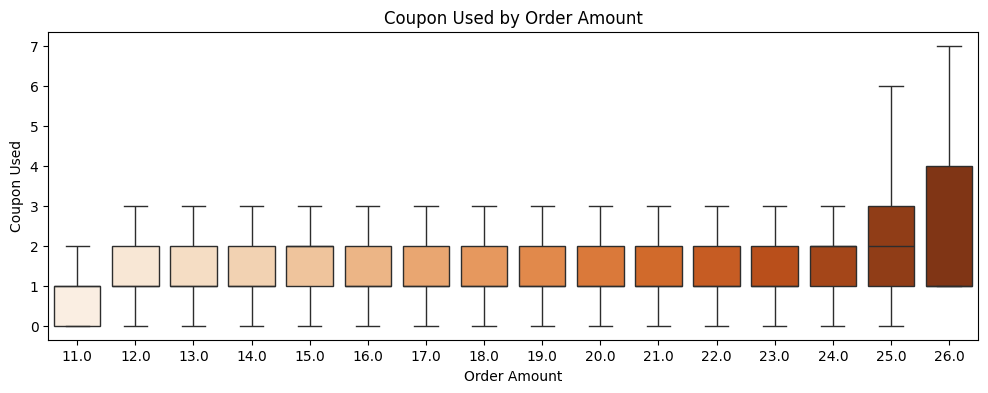

In [25]:
# CouponUsed vs OrderAmountHikeFromlastYear
orange_palette = sns.color_palette("Oranges", n_colors=16)

plt.figure(figsize=(12, 4))
sns.boxplot(
    x='OrderAmountHikeFromlastYear',
    y='CouponUsed',
    data=df_eda,
    showfliers=False,
    palette=orange_palette
)

plt.xlabel('Order Amount')
plt.ylabel('Coupon Used')
plt.title('Coupon Used by Order Amount')

plt.show()

- 일반적으로 주문량에 관계없이 평균 1~2개의 쿠폰을 사용
-> 쿠폰 사용과 주문 금액 사이에는 강한 상관관계 X

In [ ]:
# SatisfactionScore vs DaySinceLastOrder
satisfaction_by_days = df_eda.groupby('SatisfactionScore').agg(
    CustomerCount=('SatisfactionScore', 'size'),
    AvgDaysLastOrder=('DaySinceLastOrder', 'mean')
).reset_index()

satisfaction_by_days

,SatisfactionScore,CustomerCount,AvgDaysLastOrder
0,1,1164,4.408935
1,2,586,4.339590
2,3,1698,4.336867
3,4,1074,4.434823
4,5,1108,4.787004


- 만족도 점수가 높아질수록 마지막 주문 이후 평균 일수가 낮아져야 함
-> 그러나 만족도 점수의 평균은 동일하게 유지되고 있음

In [27]:
# CashbackAmount vs Complain 데이터 준비
bins = list(range(0, 351, 25))
labels = [f'{i}-{i+25}' for i in bins[:-1]]

cashback_groups_series = pd.cut(
    df_eda['CashbackAmount'],
    bins=bins,
    labels=labels,
    right=False
)

combined_df = pd.DataFrame({
    'CashbackGroup': cashback_groups_series,
    'Complain': df_eda['Complain']
})

cashback_by_complain = combined_df.groupby(
    ['CashbackGroup', 'Complain']
).size().reset_index(name='Count')

total_counts = cashback_by_complain.groupby('Complain')['Count'].sum().reset_index(name='TotalCount')

cashback_by_complain = cashback_by_complain.merge(total_counts, on='Complain')

cashback_by_complain['Percentage'] = (
    cashback_by_complain['Count'] / cashback_by_complain['TotalCount']
) * 100

cashback_by_complain_pivot = cashback_by_complain.pivot(
    index='CashbackGroup',
    columns='Complain',
    values=['Count', 'Percentage']
).fillna(0).reset_index()

cashback_by_complain_pivot

CashbackGroup   Count        Percentage           
Complain                     0      1          0          1
0                 0-25     4.0    1.0   0.099354   0.062344
1                25-50     4.0    1.0   0.099354   0.062344
2                50-75     0.0    1.0   0.000000   0.062344
3               75-100     0.0    1.0   0.000000   0.062344
4              100-125   292.0  140.0   7.252856   8.728180
5              125-150  1034.0  398.0  25.683060  24.812968
6              150-175  1159.0  432.0  28.787879  26.932668
7              175-200   600.0  240.0  14.903130  14.962594
8              200-225   304.0  119.0   7.550919   7.418953
9              225-250   182.0  100.0   4.520616   6.234414
10             250-275   138.0   69.0   3.427720   4.301746
11             275-300   193.0   62.0   4.793840   3.865337
12             300-325   116.0   40.0   2.881272   2.493766

In [28]:
# CashbackAmount vs Complain
cashback_by_complain['Complain'] = cashback_by_complain['Complain'].astype(bool)

fig = px.bar(
    cashback_by_complain,
    x='CashbackGroup',
    y='Percentage',
    color='Complain',
    barmode='group',
    color_discrete_map={False: 'lightgreen', True: 'red'},
    labels={
        'CashbackGroup': 'Cashback Group',
        'Percentage': 'Percentage',
        'Complain': 'Complain'
    },
    title='Cashback Percentage by Complain',
    hover_data={'CashbackGroup': True, 'Percentage': ':,.2f', 'Complain': False}
)

fig.for_each_trace(lambda trace: trace.update(name='Yes' if trace.name == 'True' else 'No'))

fig.update_layout(
    xaxis_title='Cashback Groups',
    yaxis_title='Percentage',
    barmode='group',
    title={'x': 0.45}
)

fig.show()

- Cashback Group과 complain 사이에는 선형 상관관계 X

In [29]:
# SatisfactionScore vs Complain 데이터 준비
satisfaction_by_complain = df_eda.groupby('SatisfactionScore').agg(
    TotalCustomers=('SatisfactionScore', 'size'),
    TotalComplaints=('Complain', 'sum')
).reset_index()

satisfaction_by_complain['ComplaintPercentage'] = (
    satisfaction_by_complain['TotalComplaints'] / satisfaction_by_complain['TotalCustomers']
) * 100

satisfaction_by_complain

,SatisfactionScore,TotalCustomers,TotalComplaints,ComplaintPercentage
0,1,1164,372,31.958763
1,2,586,170,29.010239
2,3,1698,472,27.797409
3,4,1074,268,24.953445
4,5,1108,322,29.061372


In [30]:
# SatisfactionScore vs Complain
blue_shades = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1E88E5', '#1976D2']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=satisfaction_by_complain['SatisfactionScore'],
    y=satisfaction_by_complain['ComplaintPercentage'],
    marker=dict(color=blue_shades)
))

fig.update_layout(
    title={
        'text': 'Complaints by Satisfaction Score',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Satisfaction Score',
    yaxis_title='Percentage',
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 40]),
    plot_bgcolor='rgba(0, 0, 0, 0)',
    bargap=0.15
)

fig.show()

- SatisfactionScore과 Complain 약간의 상관관계 존재

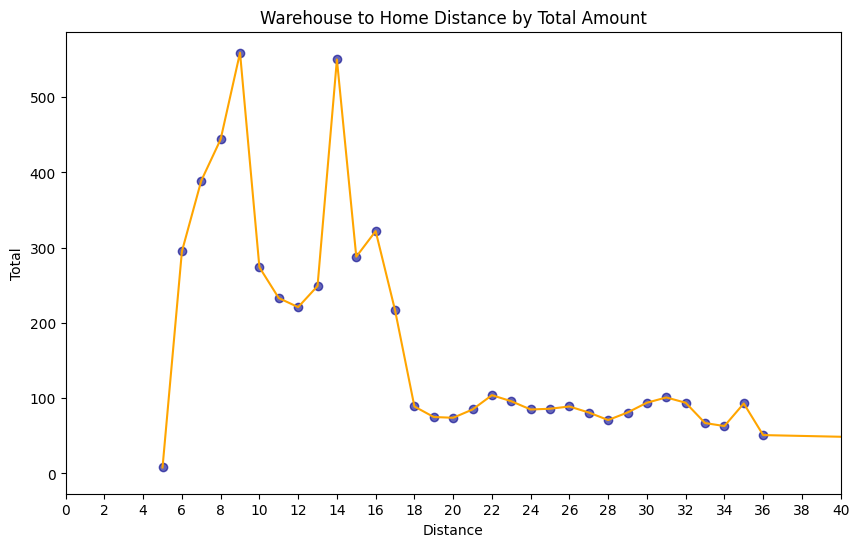

In [31]:
# WarehouseToHome vs Count
warehouse_to_home = df_eda['WarehouseToHome'].value_counts().reset_index()
warehouse_to_home.columns = ['WarehouseToHome', 'Count']
warehouse_to_home = warehouse_to_home.sort_values('WarehouseToHome')

plt.figure(figsize=(10, 6))
plt.scatter(
    warehouse_to_home['WarehouseToHome'],
    warehouse_to_home['Count'],
    alpha=0.6,
    color='darkblue'
)
plt.plot(
    warehouse_to_home['WarehouseToHome'],
    warehouse_to_home['Count'],
    linestyle='-',
    color='orange'
)

plt.xlabel('Distance')
plt.ylabel('Total')
plt.title('Warehouse to Home Distance by Total Amount')
plt.grid(which='both', linestyle='None')

plt.xlim(0, 40)
plt.xticks(range(0, 41, 2))

plt.show()

- 대부분의 고객은 6~16km 떨어져 있음
->  거리가 멀어질수록 고객 수는 감소
- 거리는 고객 결정에 중요한 요소임

### EDA Summary
- 대부분의 고객이 이탈하지 않음
→ 타겟 변수(Churn)가 불균형 데이터(imbalanced) 형태임
→ 모델링할 때 클래스 불균형 처리 필요
- Nominal과 Ordinal변수 모두에서 이탈 패턴 차이가 있음
→ 범주형 변수들이 단순 정보 X
→ 이탈 여부를 설명하는 데 의미 있는 변수
- Satisfaction, complaints(Recency 관련 변수)이 특히 중요해 보임
→ 고객 행동과 직결된 변수
→ 이탈 예측에 핵심 feature로 사용될 가능성 높음
- 수치형 변수들은 분포가 다르고 skewness가 존재함
→ 정규분포가 아닐 가능성이 있음
- 행동 및 거래 관련 변수들이 모델링에 유용
→ 실제로 모델 성능을 높이는 핵심 feature 후보들